# Character topic profiles

### Pakages

In [11]:
import pandas as pd

### Loading data

In [12]:
# Load already-integrated Person 2 output
character_spells = pd.read_csv("character_spell_df.csv")
print(character_spells.head())

   Character ID    Character Name        Spell Name         Incantation  \
0             2       Ron Weasley   Unlocking Charm           alohomora   
1            59   Filius Flitwick  Levitation Charm  wingardium leviosa   
2             3  Hermione Granger  Levitation Charm  wingardium leviosa   
3             2       Ron Weasley  Levitation Charm  wingardium leviosa   
4             3  Hermione Granger   Unlocking Charm           alohomora   

                   Topic Label   Topic_0   Topic_1   Topic_2   Topic_3  Uses  \
0  LDA Topic 1: Offensive/Dark  0.200922  0.292945  0.254879  0.251255     1   
1  LDA Topic 1: Offensive/Dark  0.094698  0.666751  0.120129  0.118421     1   
2  LDA Topic 1: Offensive/Dark  0.094698  0.666751  0.120129  0.118421     1   
3  LDA Topic 1: Offensive/Dark  0.094698  0.666751  0.120129  0.118421     1   
4  LDA Topic 1: Offensive/Dark  0.200922  0.292945  0.254879  0.251255     1   

   Topic_0_weighted  Topic_1_weighted  Topic_2_weighted  Topic_3_wei

### Create weighted probabilistic character profiles


In [13]:
topic_cols = ["Topic_0", "Topic_1", "Topic_2", "Topic_3"]

# Rename for clarity
topic_cols_renamed = {
    "Topic_0": "Control_Utility_Prob",
    "Topic_1": "Defensive_Healing_Prob", 
    "Topic_2": "Revealing_Other_Prob",
    "Topic_3": "Offensive_Dark_Prob"
}

# Weight topic probabilities by spell usage frequency
for col in topic_cols:
    character_spells[col + "_weighted"] = (
        character_spells[col] * character_spells["Uses"]
    )

# Aggregate per character
character_topic_profiles = (
    character_spells
    .groupby("Character Name")
    .apply(lambda g: pd.Series({
        col: g[col + "_weighted"].sum() / g["Uses"].sum()
        for col in topic_cols
    }))
    .reset_index()
)

# Determine dominant topic
character_topic_profiles["Dominant Topic"] = (
    character_topic_profiles[topic_cols].idxmax(axis=1)
)

# Human-readable labels
topic_label_lookup = {
    "Topic_0": "Control/Utility",
    "Topic_1": "Defensive/Healing",
    "Topic_2": "Revealing/Other",
    "Topic_3": "Offensive/Dark"
}

character_topic_profiles["Character Profile"] = (
    character_topic_profiles["Dominant Topic"].map(topic_label_lookup)
)



C:\Users\phili\AppData\Local\Temp\ipykernel_7348\274760247.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [14]:
# Calculate how "dominant" each topic really is (entropy measure)
from scipy.stats import entropy
import numpy as np

character_topic_profiles['Topic_Concentration'] = (
    character_topic_profiles[topic_cols]
    .apply(lambda row: 1 - (entropy(row) / np.log(len(topic_cols))), axis=1)
)
# Values close to 1 = strong profile; close to 0 = mixed profile

# Preview
print(character_topic_profiles.head(10))

        Character Name   Topic_0   Topic_1   Topic_2   Topic_3 Dominant Topic  \
0     Albus Dumbledore  0.215129  0.159495  0.349157  0.276219        Topic_2   
1                  All  0.623379  0.138070  0.120129  0.118421        Topic_0   
2  Bellatrix Lestrange  0.200922  0.292945  0.254879  0.251255        Topic_1   
3     Dolores Umbridge  0.406383  0.218983  0.187504  0.187130        Topic_0   
4         Draco Malfoy  0.036893  0.054161  0.046453  0.862493        Topic_3   
5      Filius Flitwick  0.094698  0.666751  0.120129  0.118421        Topic_1   
6         Fred Weasley  0.611845  0.145022  0.120129  0.123004        Topic_0   
7       George Weasley  0.611845  0.145022  0.120129  0.123004        Topic_0   
8               Ghosts  0.094698  0.138070  0.648810  0.118421        Topic_2   
9    Gilderoy Lockhart  0.200922  0.292945  0.254879  0.251255        Topic_1   

   Character Profile  Topic_Concentration  
0    Revealing/Other             0.028988  
1    Control/Utility

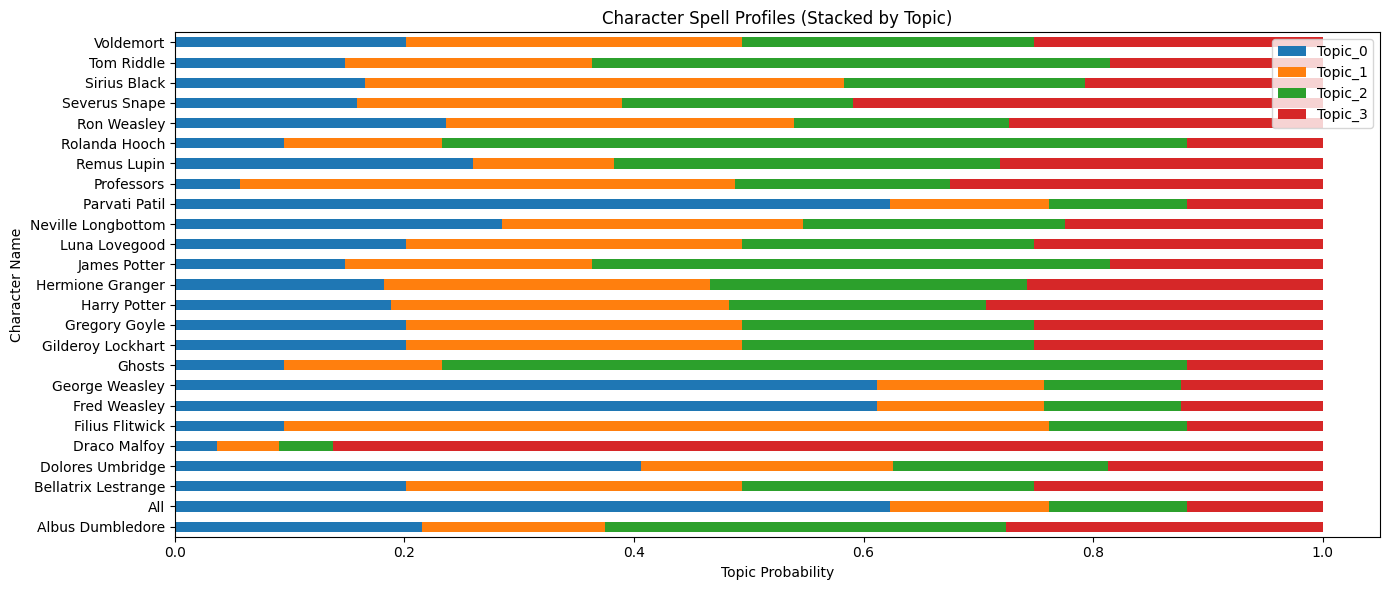

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))
character_topic_profiles.set_index("Character Name")[topic_cols].plot(
    kind='barh', stacked=True, ax=ax
)
ax.set_xlabel("Topic Probability")
ax.set_title("Character Spell Profiles (Stacked by Topic)")
plt.tight_layout()

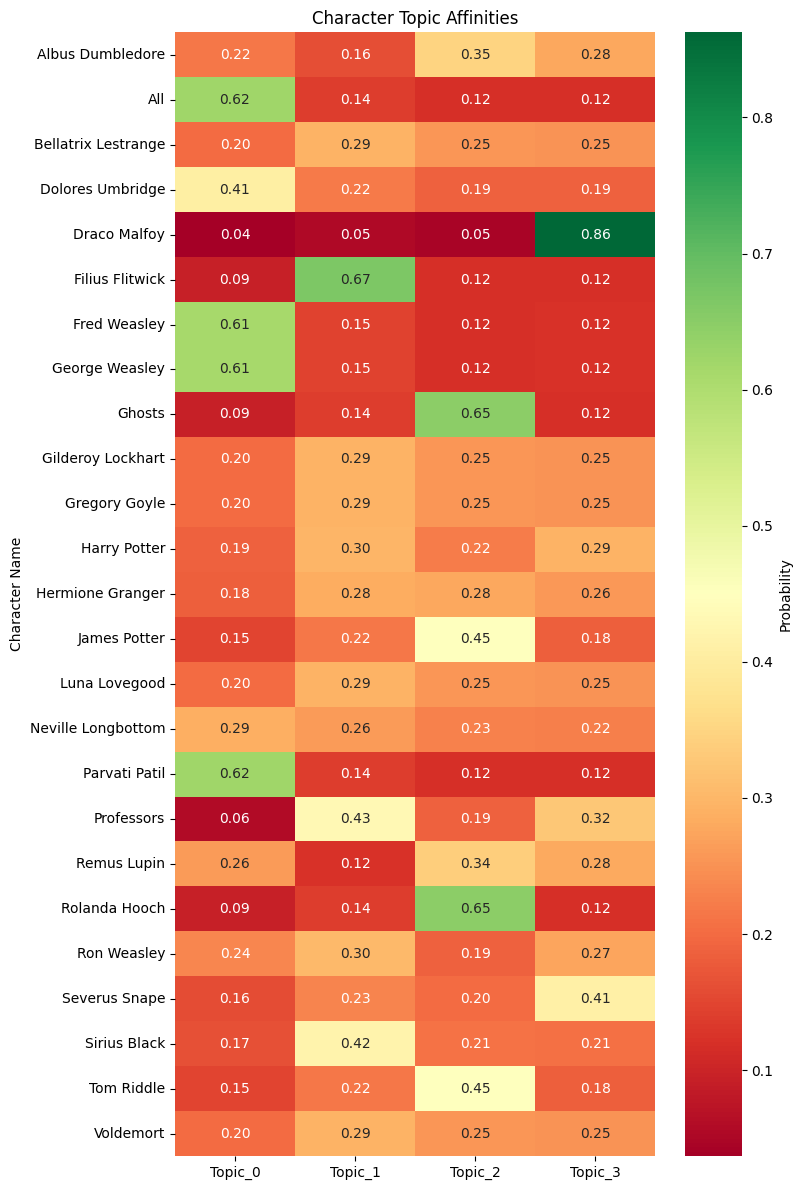

In [ ]:
import seaborn as sns

# Select specific characters (modify this list as needed)
selected_characters = [
    "Harry Potter",
    "Voldemort",
    "Albus Dumbledore",
    "Hermione Granger",
    "Ron Weasley",
    "Severus Snape",
    "Minerva McGonagall",
    "Bellatrix Lestrange"
]

# Filter to only characters that exist in the data
available_characters = character_topic_profiles["Character Name"].tolist()
selected_characters = [char for char in selected_characters if char in available_characters]

# Create heatmap with selected characters
filtered_data = character_topic_profiles[
    character_topic_profiles["Character Name"].isin(selected_characters)
].set_index("Character Name")[topic_cols]

fig, ax = plt.subplots(figsize=(8, max(4, len(selected_characters) * 0.4)))
sns.heatmap(
    filtered_data,
    annot=True, fmt='.2f', cmap='RdYlGn', ax=ax, 
    cbar_kws={'label': 'Probability'},
    vmin=0, vmax=1
)
ax.set_title("Character Topic Affinities")
plt.tight_layout()

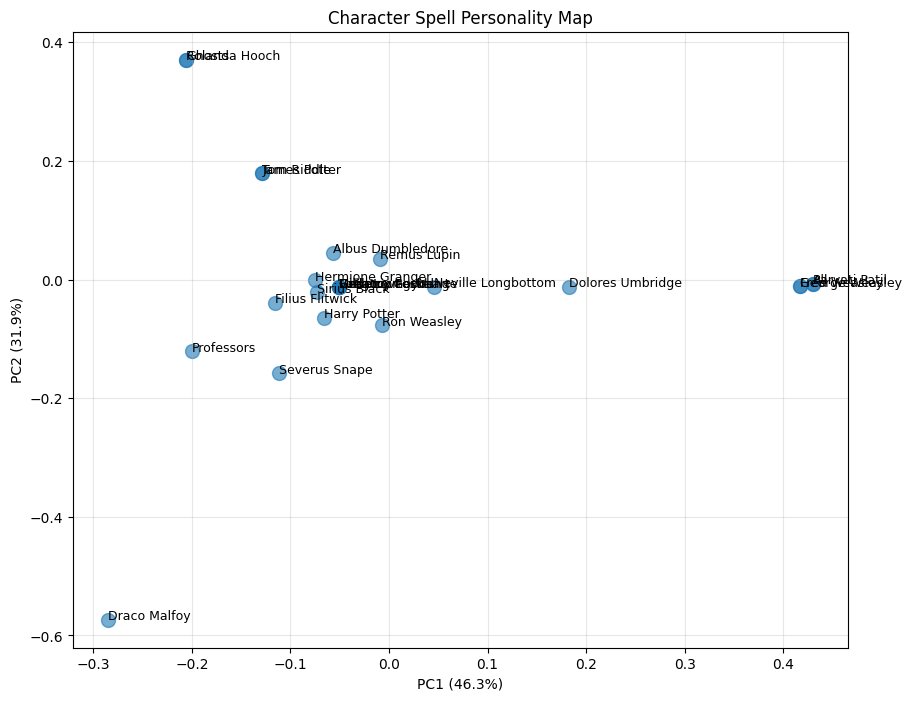

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords = pca.fit_transform(character_topic_profiles[topic_cols])

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(coords[:, 0], coords[:, 1], s=100, alpha=0.6)
for idx, char in enumerate(character_topic_profiles["Character Name"]):
    ax.annotate(char, (coords[idx, 0], coords[idx, 1]), fontsize=9)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title("Character Spell Personality Map")
plt.grid(True, alpha=0.3)

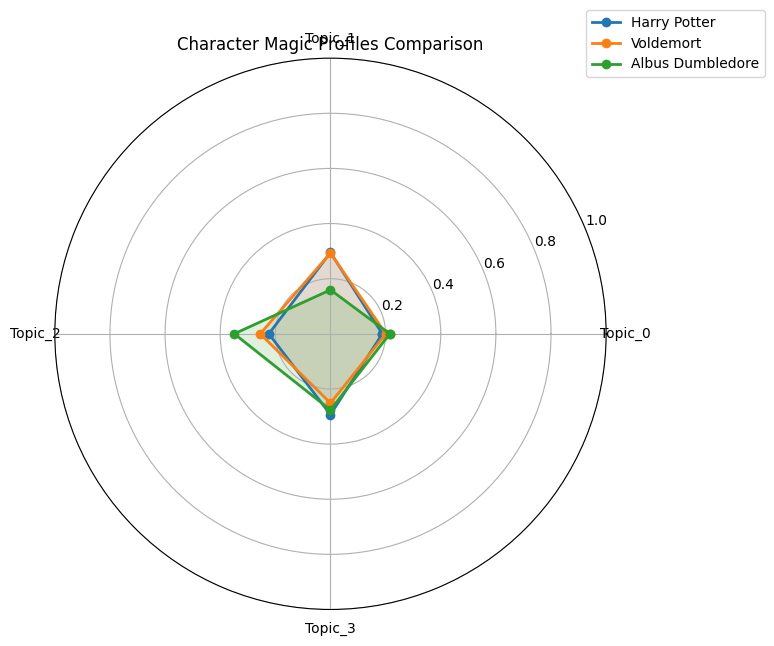

In [18]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

characters_to_plot = ['Harry Potter', 'Voldemort', 'Albus Dumbledore']
angles = np.linspace(0, 2*np.pi, len(topic_cols), endpoint=False).tolist()
angles += angles[:1]  # Complete the circle

for char in characters_to_plot:
    if char in character_topic_profiles["Character Name"].values:
        row = character_topic_profiles[character_topic_profiles["Character Name"] == char].iloc[0]
        values = row[topic_cols].tolist()
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=char)
        ax.fill(angles, values, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(topic_cols)
ax.set_ylim(0, 1)
ax.set_title("Character Magic Profiles Comparison")
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()

In [19]:
# Show min/max/mean for each topic
for col in topic_cols:
    print(f"{col}:")
    print(f"  Mean: {character_topic_profiles[col].mean():.3f}")
    print(f"  Std:  {character_topic_profiles[col].std():.3f}")
    print(f"  Min:  {character_topic_profiles[col].min():.3f}")
    print(f"  Max:  {character_topic_profiles[col].max():.3f}")

Topic_0:
  Mean: 0.250
  Std:  0.180
  Min:  0.037
  Max:  0.623
Topic_1:
  Mean: 0.247
  Std:  0.127
  Min:  0.054
  Max:  0.667
Topic_2:
  Mean: 0.260
  Std:  0.152
  Min:  0.046
  Max:  0.649
Topic_3:
  Mean: 0.242
  Std:  0.150
  Min:  0.118
  Max:  0.862
